# Raw soil-moisture profile `SWC_FF1` (2020-2025) from database (influxdb)

***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Variable**: `SWC_FF1_*_1`, all five depths (`0.05`, `0.1`, `0.2`, `0.3`, `0.5` m) &nbsp;&nbsp;|&nbsp;&nbsp; **Period**: 2020-2025  
**Produces**: `SWC_FF1_PROFILE_RAW_2020-2025.parquet` — the raw profile, values only, on local `TIMESTAMP_END`  
**Consumed by**: the five per-depth screening notebooks in this folder, as their cross-check reference  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

## ℹ️ About this notebook
Download the **raw** `SWC_FF1` soil profile — all five depths at once — from the InfluxDB database and write it to a single parquet file. Nothing is screened, corrected, resampled or uploaded here. This notebook is pure I/O.

**Why it exists.** Each of the five per-depth screening notebooks (`SWC_FF1_0.05_1`, `0.1`, `0.2`, `0.3`, `0.5`) cross-checks its target against the rest of the profile, and each of them used to download *all five* raw depths in order to do so: about 2.5 million records, roughly five minutes — five times over, for the very same data. This notebook downloads it **once**. Each screening notebook now reads its four companion depths from the file written here, and downloads only its own target from the database.

**Flow:** connect → download the five raw fields → check the frame → write parquet → read the file back and verify.

> **Database access** needs the `influxdb-client` package, which this project pulls in via the **`diive[db]` extra** (declared in `pyproject.toml`). Note that diive *also* ships a `db` dependency group, but dependency groups are local to the project that declares them — `uv sync --group db` only works inside the diive repo, not from here. From this repo the extra is the only route.

### 💡 Values only, on purpose — this file carries no database tags
`InfluxIO.download` returns two views of the same query: `data_simple`, a plain DataFrame with one column per field, and `data_detailed`, a dict `{field: DataFrame}` in which every field carries **its database tags** (`units`, `gain`, `offset`, `hpos`/`vpos`, `data_version`, …). **This notebook saves `data_simple` — the values, without the tags.**

This is the single most important thing to understand about the file, so it is worth stating plainly:

- **What the file is for.** It serves the **companion** depths in the per-depth screening notebooks, and those are used for one purpose only: the **30MIN cross-check** — half-hourly means of the other depths, compared against the depth being screened. A mean needs values and timestamps. Nothing in that comparison reads a tag.
- **What the file is *not* for.** It cannot stand in for a screening notebook's own download. `StepwiseMeteoScreeningDb` is constructed from `data_detailed` and **needs the tags**: they travel with the series through screening and are written back to the database on upload. A tagless frame would silently lose them.

So each screening notebook still downloads **its own target variable live from the database**, with tags, and reads only its **four companions** from this file. That turns five full-profile downloads into one full-profile download plus five single-variable ones.

### ⚠️ This file is raw and unscreened — read this before using it
It is the raw database record exactly as stored, which means every artefact is still in it. A consumer that treats it as clean data will be wrong in specific, known ways:

- **A failed sensor read is a number, not a gap.** The CR1000 firmware predates SDI-12 NaN support (a deliberate decision logged on 2020-04-10), so a read that fails lands in the record as that sensor's calibration polynomial evaluated at zero response — a **fixed negative value per sensor** (−14.4, −19.8, −20.9, −64.6, −69.6 …). `notna()` therefore does **not** mean "measured". Filter on a physical range (`0` … `60` % VWC at this site) before using any value from this file.
- **The 5 cm probe is decoupled from 2020-08-01 to 2020-10-24.** Through that window `SWC_FF1_0.05_1` keeps producing smooth, in-range, plausibly drifting values while 242 mm of rain fails to move it — the backfill had settled away from the prongs in the probe's first dry summer. No statistical test can see it. **Any consumer that builds a profile mean as a reference must mask that window out of the 0.05 m column** — the screening notebooks do. This is a real trap: the values look perfectly fine.
- **`0.3` holds two different sensors under one field name.** The original probe failed in April 2024 and was unplugged on 2024-04-23; the replacement went in on 2025-03-04, but about **40 cm downslope** because the old one could not be pulled, and its level differs by roughly **3 % VWC**. Between 2024-04-11 and 2025-03-04 there is no 0.3 m measurement at all (hence its ~450 000 missing records). A companion mean that simply averages "whatever is present" therefore **changes membership mid-record** — and steps at the changeover. Decide deliberately what to do about that; do not let it happen by accident.
- **Two raw time resolutions.** 10MIN until the March 2021 logger rebuild, 1MIN after, plus a handful of stray 2/3/5/6-minute records from the April 2024 SDI-12 bus failure. The frequency-group report below makes them visible.

Screening decisions belong in the per-depth notebooks, not here. This notebook removes nothing.

## ⏱️ Timestamp convention (important)
The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`** (the stamp marks the *end* of the averaging interval).

The single knob is `TIMEZONE_OFFSET_TO_UTC_HOURS` (set in *User settings*). `InfluxIO.download` applies it on download, so what comes back — and what this notebook writes — is **local time (UTC+1), timezone-naive, `TIMESTAMP_END`**.

| Stage | Timezone | Convention | Done by |
|---|---|---|---|
| Database | UTC | `TIMESTAMP_END` | InfluxDB |
| After `dbc.download(..., timezone_offset_to_utc_hours=N)` | local (UTC+N) | `TIMESTAMP_END` | InfluxIO |
| **This parquet file** | **local (UTC+N)** | **`TIMESTAMP_END`** | this notebook |
| In the screening notebooks | local | `TIMESTAMP_END`, resampled to 30MIN means | consumer |

Nothing is converted to `TIMESTAMP_MID` here — that conversion happens inside `StepwiseMeteoScreeningDb`, on the target variable, in the screening notebooks. The cross-check those notebooks run works on `TIMESTAMP_END` as downloaded, which is exactly what this file holds, so consumer and file agree with no shift in between. `TIMEZONE_OFFSET_TO_UTC_HOURS` **must match the value used in the screening notebooks** (`1`); if it ever changes, this file has to be rewritten with it.

## 🔁 When this notebook must be re-run
Re-run it — **before** the screening notebooks — whenever

- the raw record is **extended** (a new year of data arrives), or
- the raw data is **re-ingested or corrected** in the database.

If it is not re-run, the screening notebooks cross-check against a **stale profile**: the companion depths simply stop before the screened period ends, and the comparison quietly covers less than it claims. The screening notebooks therefore *assert* that this file covers the period they screen, so a stale file **fails loudly** instead of silently. That assertion is the safety net; re-running this notebook is the fix.

Re-running is idempotent — the parquet is overwritten in place. When the period grows, update `STOP` and the year range in `OUTNAME` (and rename this notebook to match), then update the readers.

## ✏️ User settings (please adjust)

Adjust these before running. What each setting means:

**Site and variables**
- `SITE`: site ID, used to build the bucket name.
- `PROFILE`, `REPL`, `DEPTHS`: the sensor position tags of the FF1 soil profile. `FIELDS` is assembled from them and holds the five InfluxDB `_field` names — the whole profile, in depth order.
- `MEASUREMENT`: exactly **one** measurement grouping the variables — `SWC` for soil water content.

**Time range to download**
- `START`: first timestamp — **is** included.
- `STOP`: upper bound — **is not** included. Mirrors the screening notebooks exactly, so the file always covers what they screen.

**Data settings**
- `TIMEZONE_OFFSET_TO_UTC_HOURS`: the critical timestamp knob — see *Timestamp convention* above. Must be the same value the screening notebooks use.
- `DATA_VERSION`: the source data version in the database (`raw`). This notebook deals only with raw data; the screened versions live in the processed bucket and are written by the per-depth notebooks.
- `DIRCONF`: local folder holding the database connection config.

**Output**
- `OUTDIR` / `OUTNAME` / `OUTPATH`: the parquet written by this notebook. It lives in the external (untracked) data folder under **the same relative path as this notebook**, and `OUTNAME` starts with this notebook's name, so code and data line up by eye.

In [1]:
# --- Site ---
SITE = 'ch-lae'

# --- Variables: the whole FF1 soil profile ---
# Five TEROS 12 probes installed 19 Mar 2020, first logged 10 Apr 2020, all five under
# measurement SWC of bucket ch-lae_raw. Listed in depth order; the exported columns
# follow this order.
PROFILE = 'FF1'  # horizontal position (soil profile)
REPL = '1'  # replicate
DEPTHS = ['0.05', '0.1', '0.2', '0.3', '0.5']
FIELDS = [f'SWC_{PROFILE}_{d}_{REPL}' for d in DEPTHS]
MEASUREMENT = 'SWC'

# --- Time range to download ---
# Raw resolution is 10MIN until the March 2021 logger rebuild and 1MIN after, so this
# range is ~2.5 million records per depth. The profile starts 2020-04-10; asking for
# 2020-01-01 simply starts at the first record.
# Keep these identical to the screening notebooks - they assert that this file covers
# the period they screen.
START = '2020-01-01 00:00:01'  # included
STOP = '2026-01-01 00:00:01'  # not included

# --- Data settings ---
DATA_VERSION = 'raw'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET, winter time). Must match how the raw data was logged.
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'

# --- Output ---
# Data files live in the external (untracked) data folder, under the same relative
# path as this notebook. OUTNAME is this notebook's name plus what the file holds.
OUTDIR = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
          r'\workflow\10_METEO\20_SCREENING\SWC')
OUTNAME = 'SWC_FF1_PROFILE_RAW_2020-2025'

## 🤖 Auto settings

### Buckets and output path (do not adjust)

In [2]:
from pathlib import Path

BUCKET_RAW = f'{SITE}_raw'  # source bucket, e.g. 'ch-lae_raw'
OUTPATH = Path(OUTDIR) / f'{OUTNAME}.parquet'

print(f'Downloading:  {FIELDS}')
print(f'From bucket:  {BUCKET_RAW}  (measurement {MEASUREMENT}, data version {DATA_VERSION})')
print(f'Period:       {START}  ->  {STOP}  (stop not included)')
print(f'Writing to:   {OUTPATH}')

Downloading:  ['SWC_FF1_0.05_1', 'SWC_FF1_0.1_1', 'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1']
From bucket:  ch-lae_raw  (measurement SWC, data version raw)
Period:       2020-01-01 00:00:01  ->  2026-01-01 00:00:01  (stop not included)
Writing to:   F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\20_SCREENING\SWC\SWC_FF1_PROFILE_RAW_2020-2025.parquet


### Imports

In [3]:
import importlib.metadata
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd

from diive.core.io.db.influx import InfluxIO  # needs influxdb-client, via the diive[db] extra
from diive.core.times.times import detect_freq_groups  # the same grouping the screening uses internally

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive v{importlib.metadata.version('diive')}")

Last run: 2026-07-22 02:02:44
diive v0.91.0


## 🧰 Helper: the validator every check goes through
One function states what a valid profile frame is, and it is used three times: on what the download returned, before writing, and on what was read back from the written file. Everything a consumer of this file silently assumes is checked in one place — index name, index type, timezone, ordering, duplicates, and that all five depths are present **and non-empty**.

It raises rather than returning `False`, so a bad frame cannot slip past an ignored return value, and it returns the frame so it can be used inline.

In [4]:
def check_profile_frame(df: pd.DataFrame, fields: list) -> pd.DataFrame:
    """Validate a raw soil-profile frame; raise ValueError if anything is off.

    Checks exactly what a reader of the exported parquet file assumes to be true:
    a DatetimeIndex named TIMESTAMP_END, timezone-naive (InfluxIO already shifted
    the UTC stamps to local time, so a tz-aware index would mean the shift was
    applied twice or not at all), sorted, without duplicate timestamps, and one
    non-empty column per requested field.

    The non-empty part matters: a field that exists in the database but returns
    nothing for the requested period comes back as a column of NaN, which is the
    one failure mode that looks like valid data to every downstream mean.

    Returns *df* unchanged, so it can be used inline.
    """
    if not isinstance(df, pd.DataFrame):
        raise ValueError(f'expected a DataFrame, got {type(df).__name__}')
    if df.empty:
        raise ValueError('the profile frame is empty')

    idx = df.index
    if not isinstance(idx, pd.DatetimeIndex):
        raise ValueError(f'index must be a DatetimeIndex, got {type(idx).__name__}')
    if idx.name != 'TIMESTAMP_END':
        raise ValueError(f"index must be named 'TIMESTAMP_END', got {idx.name!r}")
    if idx.tz is not None:
        raise ValueError(f'index must be timezone-naive local time, got tz={idx.tz}')
    if not idx.is_monotonic_increasing:
        raise ValueError('index is not monotonically increasing')
    if idx.has_duplicates:
        raise ValueError(f'index has {int(idx.duplicated().sum())} duplicate timestamp(s)')

    missing = [f for f in fields if f not in df.columns]
    if missing:
        raise ValueError(f'missing column(s): {missing}')
    empty = [f for f in fields if df[f].notna().sum() == 0]
    if empty:
        raise ValueError(f'column(s) without a single value in this period: {empty}')
    return df

### Negative control
`check_profile_frame` is the only guard between a broken download and a parquet file that five other notebooks trust. A validator that quietly accepts anything is worse than none at all, so prove it rejects each failure mode it claims to catch — and accepts a good frame.

In [5]:
_good = pd.DataFrame(
    {f: [21.0, 21.1, 21.2] for f in FIELDS},
    index=pd.DatetimeIndex(pd.date_range('2020-04-10 15:00:00', periods=3, freq='10min'),
                           name='TIMESTAMP_END'))
check_profile_frame(_good, FIELDS)  # must NOT raise
print('PASSED - a valid frame is accepted')

_wrong_name = _good.copy()
_wrong_name.index = _good.index.rename('TIMESTAMP_MID')

_tz_aware = _good.copy()
_tz_aware.index = _good.index.tz_localize('UTC')

_all_nan = _good.copy()
_all_nan[FIELDS[2]] = float('nan')

for _bad, _why in [(_wrong_name, 'index named TIMESTAMP_MID instead of TIMESTAMP_END'),
                   (_tz_aware, 'timezone-aware index'),
                   (_good.drop(columns=[FIELDS[3]]), 'a missing depth column'),
                   (_good.iloc[[0, 0, 1]], 'duplicate timestamps'),
                   (_good.iloc[::-1], 'index not sorted'),
                   (_all_nan, 'a depth column that is all NaN'),
                   (_good.iloc[0:0], 'an empty frame')]:
    try:
        check_profile_frame(_bad, FIELDS)
    except ValueError as e:
        print(f'PASSED - {_why} raises: {e}')
    else:
        raise AssertionError(f'(!) FAILED - check_profile_frame accepted {_why}')

PASSED - a valid frame is accepted
PASSED - index named TIMESTAMP_MID instead of TIMESTAMP_END raises: index must be named 'TIMESTAMP_END', got 'TIMESTAMP_MID'
PASSED - timezone-aware index raises: index must be timezone-naive local time, got tz=UTC
PASSED - a missing depth column raises: missing column(s): ['SWC_FF1_0.3_1']
PASSED - duplicate timestamps raises: index has 1 duplicate timestamp(s)
PASSED - index not sorted raises: index is not monotonically increasing
PASSED - a depth column that is all NaN raises: column(s) without a single value in this period: ['SWC_FF1_0.2_1']
PASSED - an empty frame raises: the profile frame is empty


## ⬇️ Download data from database

### Connect to database

In [6]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

Optional — list all fields available in the measurement (does not check the selected time range):

In [7]:
display(dbc.show_fields_in_measurement(bucket=BUCKET_RAW, measurement=MEASUREMENT))

> Fields in measurement SWC of bucket ch-lae_raw:

> Found 16 fields in measurement SWC of bucket ch-lae_raw.

['SWC_FF1_0.05_1',
 'SWC_FF1_0.1_1',
 'SWC_FF1_0.2_1',
 'SWC_FF1_0.3_1',
 'SWC_FF1_0.5_1',
 'SWC_FF3_0.05_1',
 'SWC_FF3_0.05_2',
 'SWC_FF3_0.1_1',
 'SWC_FF3_0.2_1',
 'SWC_FF3_0.3_1',
 'SWC_FF3_0.4_1',
 'SWC_FF3_0.5_1',
 'SWC_M5_0.05_1',
 'SWC_M5_0.1_1',
 'SWC_M5_0.2_1',
 'SWC_M5_0.3_1']

### Download the whole profile
One query, five fields. Returns three objects:

- `data_simple`: the high-res time series, one column per field — **this is what gets saved**.
- `data_detailed`: dict `{field: DataFrame}` with each field's series **and its database tags** — not saved, see *Values only, on purpose* above.
- `assigned_measurements`: the auto-detected measurement per field (a sanity check).

⏳ **This is the slow cell** — about 2.5 million records over five fields, roughly **5 minutes**. It is the entire reason this notebook exists: run it once here instead of five times across the screening notebooks.

In [8]:
%%time
data_simple, data_detailed, assigned_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)

> DOWNLOADING from bucket ch-lae_raw: variables ['SWC_FF1_0.05_1', 'SWC_FF1_0.1_1', 
'SWC_FF1_0.2_1', 'SWC_FF1_0.3_1', 'SWC_FF1_0.5_1'] from measurements ['SWC'], data version ['raw'], 
between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 5 variables:

CPU times: total: 3min 21s
Wall time: 4min 39s


## 🔍 Check what came back
Nothing here is optional. The file written below is trusted by five other notebooks, and every one of the assumptions they make about it is asserted here rather than hoped for.

In [9]:
data_simple

,SWC_FF1_0.05_1,SWC_FF1_0.1_1,SWC_FF1_0.2_1,SWC_FF1_0.3_1,SWC_FF1_0.5_1
TIMESTAMP_END,,,,,
2020-04-10 15:00:00,30.90000,30.30000,32.90000,28.70000,25.50000
2020-04-10 15:10:00,30.90000,30.30000,32.90000,28.70000,25.50000
2020-04-10 15:20:00,30.90000,30.30000,32.90000,28.70000,25.50000
2020-04-10 15:30:00,30.90000,30.30000,32.90000,28.70000,25.50000
2020-04-10 15:40:00,30.90000,30.30000,32.90000,28.70000,25.50000
...,...,...,...,...,...
2025-12-31 23:56:00,29.51567,30.72553,32.16367,30.39291,25.20261
2025-12-31 23:57:00,29.54534,30.71390,32.14912,30.38806,25.22045
2025-12-31 23:58:00,29.51160,30.72747,32.09792,30.35877,25.19388


In [10]:
# The five fields must all come from the SWC measurement, and nothing else may have
# slipped into the query.
display(assigned_measurements)
assert set(assigned_measurements.keys()) == set(FIELDS), (
    f'(!) unexpected fields returned: {sorted(set(assigned_measurements) ^ set(FIELDS))}')
assert set(assigned_measurements.values()) == {MEASUREMENT}, (
    f'(!) unexpected measurement(s): {sorted(set(assigned_measurements.values()))}')
print(f'OK - all {len(FIELDS)} fields assigned to measurement {MEASUREMENT}')

{'SWC_FF1_0.05_1': 'SWC',
 'SWC_FF1_0.1_1': 'SWC',
 'SWC_FF1_0.2_1': 'SWC',
 'SWC_FF1_0.3_1': 'SWC',
 'SWC_FF1_0.5_1': 'SWC'}

OK - all 5 fields assigned to measurement SWC


### Coverage and period
The per-column non-null counts are the quickest way to see that the download is complete and that the one expected hole is the one you expect.

As of the run of 21 Jul 2026 (raw record through 2025), this query returned **2 509 501 rows**, first `2020-04-10 15:00:00`, last `2026-01-01 00:00:00`:

| field | records with a value |
|---|---|
| `SWC_FF1_0.05_1` | 2 503 323 |
| `SWC_FF1_0.1_1` | 2 504 415 |
| `SWC_FF1_0.2_1` | 2 504 840 |
| `SWC_FF1_0.3_1` | **2 058 795** |
| `SWC_FF1_0.5_1` | 2 506 148 |

`0.3` is about 450 000 records short of the others because that probe was **dead from 2024-04-11 to 2025-03-04** (failed, unplugged 2024-04-23, replaced 2025-03-04). That is the expected hole. Any *other* column falling behind is not, and means something went wrong with the download.

In [11]:
_report = pd.DataFrame({'records': data_simple.count()})
_report['missing'] = len(data_simple) - _report['records']
_report['coverage [%]'] = (_report['records'] / len(data_simple) * 100).round(2)
_report['first'] = [data_simple[c].first_valid_index() for c in _report.index]
_report['last'] = [data_simple[c].last_valid_index() for c in _report.index]
display(_report)

print(f'rows:  {len(data_simple):,}')
print(f'first: {data_simple.index[0]}')
print(f'last:  {data_simple.index[-1]}')
print(f'index: name={data_simple.index.name!r}, dtype={data_simple.index.dtype}, tz={data_simple.index.tz}')

,records,missing,coverage [%],first,last
SWC_FF1_0.05_1,2503323,6178,99.75,2020-04-10 15:00:00,2026-01-01
SWC_FF1_0.1_1,2504415,5086,99.80,2020-04-10 15:00:00,2026-01-01
SWC_FF1_0.2_1,2504840,4661,99.81,2020-04-10 15:00:00,2026-01-01
SWC_FF1_0.3_1,2058795,450706,82.04,2020-04-10 15:00:00,2026-01-01
SWC_FF1_0.5_1,2506148,3353,99.87,2020-04-10 15:00:00,2026-01-01


rows:  2,509,501
first: 2020-04-10 15:00:00
last:  2026-01-01 00:00:00
index: name='TIMESTAMP_END', dtype=datetime64[us], tz=None


### Validate the frame
The same validator the written file is checked with, applied to what the database returned. If this raises, nothing is written.

In [12]:
check_profile_frame(data_simple, FIELDS)
print(f'OK - valid profile frame: {len(data_simple):,} rows x {len(data_simple.columns)} depths, '
      f'{data_simple.index[0]} -> {data_simple.index[-1]}')

# The period requested must actually be covered - a silently short download is exactly the
# kind of staleness the screening notebooks would otherwise inherit.
assert data_simple.index[-1] < pd.Timestamp(STOP), '(!) records at or beyond STOP - check the query'
print(f'Period requested: {START} -> {STOP} (stop not included). '
      f'Covered: {data_simple.index[0]} -> {data_simple.index[-1]}')

OK - valid profile frame: 2,509,501 rows x 5 depths, 2020-04-10 15:00:00 -> 2026-01-01 00:00:00
Period requested: 2020-01-01 00:00:01 -> 2026-01-01 00:00:01 (stop not included). Covered: 2020-04-10 15:00:00 -> 2026-01-01 00:00:00


### The raw record has two time resolutions
The profile is **10MIN until the March 2021 logger rebuild and 1MIN after it** (fieldbook 2021-03-24/26: the FF1 logger box was rebuilt and a new program uploaded; the sensors themselves were only reconnected, not replaced). The database keeps both eras under the same field names, so this single frame has a spacing that changes partway through.

This is reported rather than fixed. The screening notebooks resample to 30MIN means with a coverage rule that is spacing-aware, and `StepwiseMeteoScreeningDb` does its own grouping (it drops any frequency group holding less than 0.2 % of the records and upsamples the coarse era onto the fine grid). Both need the raw spacing intact, so this file keeps it.

The stray 2/3/5/6-minute groups below are the April 2024 SDI-12 bus failure — they are what diive discards as sub-0.2 % groups.

In [13]:
_freqgroups = detect_freq_groups(index=data_simple.index)
_counts = _freqgroups.value_counts()
print(f'{"freq [s]":>10s} {"records":>10s} {"share":>8s}   first record        last record')
for _f in _counts.index:
    _ix = _freqgroups[_freqgroups == _f].index
    _share = len(_ix) / len(_freqgroups) * 100
    _kept = 'used' if _share > 0.2 else 'dropped by diive (< 0.2%)'
    print(f'{_f:10.0f} {len(_ix):10d} {_share:7.2f}%   {_ix[0]}  {_ix[-1]}   {_kept}')

  freq [s]    records    share   first record        last record
        60    2459188   98.00%   2021-03-26 15:23:00  2026-01-01 00:00:00   used
       600      50079    2.00%   2020-04-10 15:00:00  2021-03-24 09:50:00   used
       120          3    0.00%   2024-04-09 11:05:00  2024-04-09 11:09:00   dropped by diive (< 0.2%)


### Quick look
Daily means of all five depths, as a plausibility check on what is about to be written. Do **not** read quality into this plot — it is the raw record: the negative failed reads are in it, the 5 cm decoupling of Aug-Oct 2020 looks perfectly smooth here, and the 0.3 m line simply stops between April 2024 and March 2025 (and returns at a different level, from a different probe).

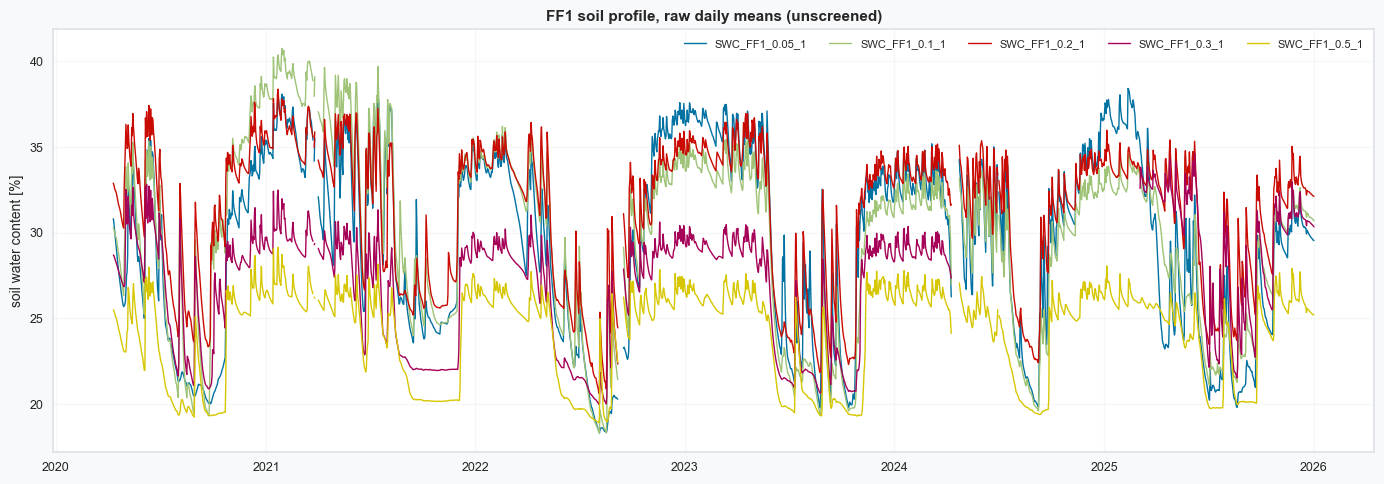

In [14]:
_daily = data_simple.resample('D').mean()
fig, ax = plt.subplots(figsize=(14, 5))
for _c in data_simple.columns:
    ax.plot(_daily.index, _daily[_c], label=_c, lw=1.0)
ax.set_ylabel('soil water content [%]')
ax.set_title('FF1 soil profile, raw daily means (unscreened)')
ax.legend(ncol=len(data_simple.columns), fontsize=8)
plt.tight_layout()
plt.show()

## 💾 Export
Write `data_simple` — values only, local `TIMESTAMP_END` — to the external data folder. The file is overwritten on every run, which is what makes re-running after a raw-data extension the whole fix.

In [15]:
OUTPATH.parent.mkdir(parents=True, exist_ok=True)  # 20_SCREENING writes almost no files, so it may not exist yet
data_simple.to_parquet(OUTPATH)
print(f'Wrote {OUTPATH}')
print(f'      {OUTPATH.stat().st_size / 1024 ** 2:.1f} MB, '
      f'{len(data_simple):,} rows x {len(data_simple.columns)} columns')

Wrote F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\20_SCREENING\SWC\SWC_FF1_PROFILE_RAW_2020-2025.parquet
      60.1 MB, 2,509,501 rows x 5 columns


### Read the written file back and verify
An export is only as good as what actually landed on disk. Read the parquet back and prove it is the same frame: same shape, same columns in the same order, identical index, identical values (`NaN` included), and valid by the same validator.

In [16]:
back = pd.read_parquet(OUTPATH)

check_profile_frame(back, FIELDS)
assert back.shape == data_simple.shape, f'(!) shape changed: {back.shape} vs {data_simple.shape}'
assert list(back.columns) == list(data_simple.columns), '(!) column set or order changed'
assert back.index.equals(data_simple.index), '(!) index changed on the round-trip'
pd.testing.assert_frame_equal(back, data_simple)  # values and dtypes, NaN-aware

print('PASSED - the file on disk is identical to what was downloaded.')
print(f'  {len(back):,} rows, {back.index[0]} -> {back.index[-1]} '
      f'(index {back.index.name!r}, tz={back.index.tz})')
display(back.count().rename('records with a value'))

PASSED - the file on disk is identical to what was downloaded.
  2,509,501 rows, 2020-04-10 15:00:00 -> 2026-01-01 00:00:00 (index 'TIMESTAMP_END', tz=None)


SWC_FF1_0.05_1    2503323
SWC_FF1_0.1_1     2504415
SWC_FF1_0.2_1     2504840
SWC_FF1_0.3_1     2058795
SWC_FF1_0.5_1     2506148
Name: records with a value, dtype: int64

## ✅ End of notebook

In [17]:
_end = datetime.now()
print(f"Finished: {_end.strftime('%Y-%m-%d %H:%M:%S')}  "
      f"(runtime {str(_end - NOTEBOOK_START).split('.')[0]})")

Finished: 2026-07-22 02:07:31  (runtime 0:04:46)


***
### 📝 Notes for this file

- **What it holds.** The five raw `SWC_FF1_*_1` depths, one float64 column each, on a timezone-naive local (UTC+1) `TIMESTAMP_END` index at the raw spacing (10MIN, then 1MIN from the March 2021 logger rebuild). Volumetric water content in **%**.
- **Values only, no tags.** Deliberate — see the section near the top. Companions are used for the 30MIN cross-check, which needs values; the screened variable keeps coming from its own live download, because `StepwiseMeteoScreeningDb` needs the database tags.
- **Raw, so still faulty.** Failed SDI-12 reads are fixed negative numbers rather than gaps; the 5 cm probe is decoupled from 2020-08-01 to 2020-10-24 while looking entirely healthy; `0.3` is two different probes under one field name with a ~11-month hole and a ~3 % VWC level change between them. Mask before averaging.
- **Nothing before 2020-04-10 belongs to this profile.** The five TEROS 12 probes were installed on 19 Mar 2020 and first logged on 10 Apr 2020. Earlier soil moisture lives under the old `SWC_M5_*` names — a different profile, different sensors, `gain` 1 — and splicing the two would join two instruments, not continue one.
- **Addressed by path.** The readers find this file by its full path, exactly like the products in `10_REFERENCE/`, so **renaming or moving it breaks every screening notebook**. If the period grows, change `OUTNAME`, this notebook's filename, and the readers together.
- **Re-run before the screening notebooks** whenever the raw record is extended or re-ingested. They assert that this file covers the period they screen, so a stale file fails loudly.
- **Not a product.** This is an internal cache of the raw database record, living in `20_SCREENING/` because that is where its readers are. It is not part of the published dataset and nothing downstream of the flux product should read it — the screened, corrected series go to the database and, for the meteo products, to `30_PRODUCTS/`.